1. Identificar y describir las variables
 variables dependientes , independientes y parametros
2. Establecer cual es el resultado esperado, de la simulacion de este modelo

3. Discretizar y resolver por diferencias finitas
 graficar y explicar el resultado


INTEGRANTES:

 Mateo Gael Figueroa

 Nataly Ramirez Machicado

 Ostin Lizandro
 
Josue Junior Camacho

### **1. Objetivo**
Calcular el precio de una opción financiera.

## Ecuación de Black-Scholes:

$$
\frac{\partial V}{\partial t} + \frac{1}{2} \sigma^{2} S^{2} \frac{\partial^{2} V}{\partial S^{2}} + rS \frac{\partial V}{\partial S} - rV = 0
$$

## Variables y parámetros

- **Variable dependiente:**
  - \$ V = V(S, t) \$: Precio de la opción financiera (función que queremos calcular).

- **Variables independientes:**
  - \$ S \$: Precio del activo subyacente.
  - \$ t \$: Tiempo.

- **Parámetros:**
  - \$ \sigma \$: Volatilidad del activo subyacente (desviación estándar de los retornos).
  - \$ r \$: Tasa de interés libre de riesgo.

## Aplicaciones
Valoración de opciones financieras y gestión de riesgos.

### **2. Resultado esperado de la simulación del modelo**
- **Objetivo del modelo:** Calcular el precio justo de una opción financiera considerando variables como el tiempo, el precio del activo subyacente, la volatilidad y la tasa libre de riesgo.

- **Resultado esperado de la simulación:**
  - Obtener el valor de la opción financiera (V) en función del tiempo (t) y el precio del activo subyacente (S).
  - La solución numérica del modelo debe cumplir la ecuación diferencial parcial de Black-Scholes:
  
  $$
    \frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0
  $$

  - El resultado permitirá conocer el precio teórico de la opción y facilitará la valoración y gestión de riesgos financieros mediante la simulación de diferentes escenarios de mercado.

- **Aplicaciones prácticas:**
  - Valoración precisa de opciones financieras.
  - Gestión y cobertura de riesgos asociados a productos derivados.
  - Toma de decisiones informadas en estrategias de inversión.


## 3. Discretización de la ecuación diferencial

Usamos un esquema de **diferencias finitas**:

- Temporal:  
  $$
  \frac{\partial V}{\partial t} \approx \frac{V_i^{n+1} - V_i^n}{\Delta t}
  $$

- Espacial (primera derivada):  
  $$
  \frac{\partial V}{\partial S} \approx \frac{V_{i+1}^n - V_{i-1}^n}{2 \Delta S}
  $$

- Espacial (segunda derivada):  
  $$
  \frac{\partial^2 V}{\partial S^2} \approx \frac{V_{i+1}^n - 2V_i^n + V_{i-1}^n}{(\Delta S)^2}
  $$

El **esquema explícito** queda:

$$
V_i^{n+1} = V_i^n + \Delta t
\left[
\frac{1}{2}\sigma^2 S_i^2 D2 + r S_i D1 - r V_i^n
\right]
$$

donde:  
- $D2 = \frac{V_{i+1}^n - 2V_i^n + V_{i-1}^n}{(\Delta S)^2}$  
- $D1 = \frac{V_{i+1}^n - V_{i-1}^n}{2\Delta S}$  

Esta fórmula sirve para calcular ($V_i^{n+1}$) a partir de los valores conocidos en tiempo (n).

### **4 Procedimiento para resolver**

- Definir un dominio para \(S\) (ej. \(S = 0\) a \(S_{\max}\)) y discretizar en puntos \(i = 0, 1, ..., M\).
- Definir un dominio para \(t\) (con tiempo final \(T\)) y discretizar en \(n = 0, 1, ..., N\).
- Establecer condiciones iniciales en \(t = T\) (valor payoff opción en vencimiento $(V_i^N)$.
- Establecer condiciones de frontera para \(S=0\) y $(S=S_{\max})$ (según tipo de opción, call o put).
- Aplicar iterativamente la fórmula discreta para obtener valores en \(t = 0\) (valor actual de la opción).




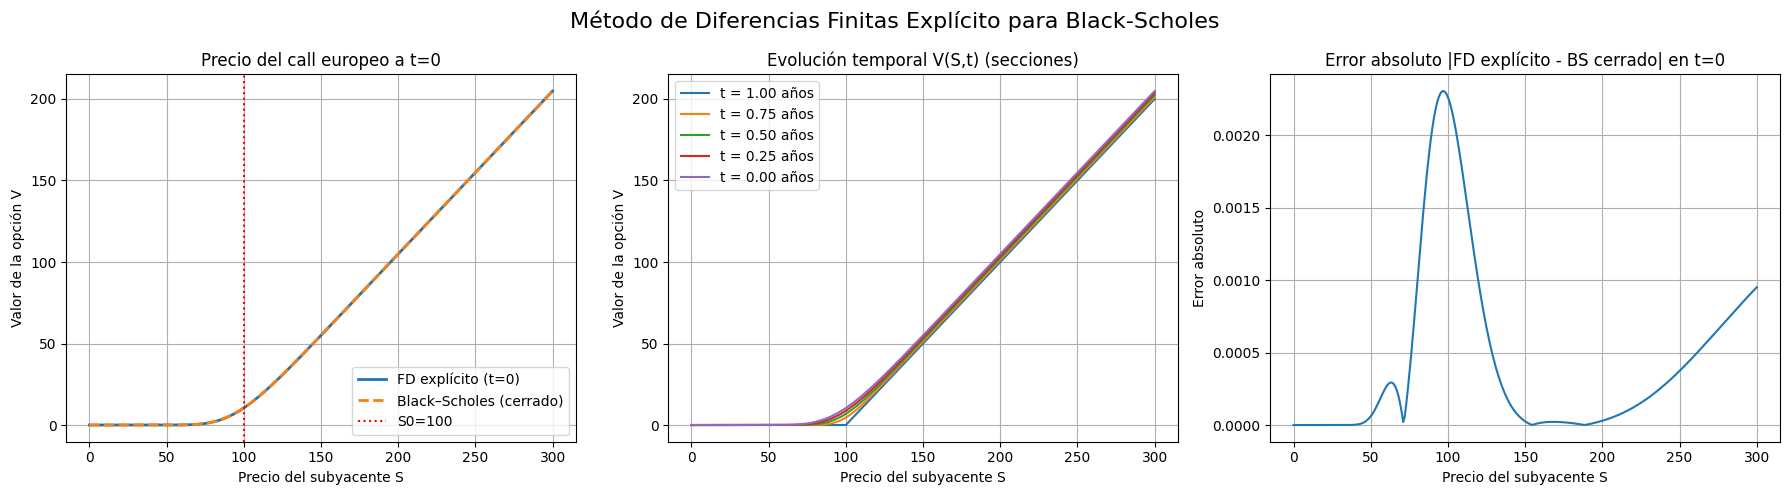

In [8]:
"""
bs_fd_explicit.py

Esquema explícito de diferencias finitas para el PDE de Black–Scholes
y comparación con la solución cerrada.

Este código resuelve numéricamente la ecuación de Black-Scholes para una opción call europea
utilizando el método explícito de diferencias finitas (FTCS - Forward Time Centered Space).
"""

import numpy as np
import matplotlib.pyplot as plt
import math

# ----------------------
# Parámetros del modelo
# ----------------------
S0 = 100.0     # precio spot actual del subyacente (solo para marcar en la gráfica)
K = 100.0      # precio de ejercicio (strike) de la opción
r = 0.05       # tasa libre de riesgo anualizada
sigma = 0.20   # volatilidad anualizada del subyacente
T = 1.0        # tiempo a vencimiento en años

# ----------------------
# Mallado numérico (discretización del dominio)
# ----------------------
S_max = 3.0 * K      # cota superior para el precio del subyacente S
N_S = 300            # número de nodos espaciales (M)
N_t = 5000           # número de pasos en tiempo (N)

# Calcula los incrementos espaciales y temporales
dS = S_max / N_S     # tamaño del paso espacial
dt = T / N_t         # tamaño del paso temporal

# Crea los vectores de precios del subyacente y tiempo transformado
S = np.linspace(0.0, S_max, N_S + 1)   # Vector de precios S_i (de 0 a S_max)
tau = np.linspace(0.0, T, N_t + 1)     # Vector de tiempo transformado tau = T - t

# ----------------------
# Condición inicial (en tau=0 equivale a t=T - vencimiento)
# ----------------------
# Payoff de una opción call europea al vencimiento: max(S - K, 0)
V = np.maximum(S - K, 0.0)
# Matriz para almacenar todas las soluciones en cada paso de tiempo
V_all = np.zeros((N_t + 1, N_S + 1))
V_all[0, :] = V.copy()  # Guarda la condición inicial

# ----------------------
# Bucle del esquema explícito (FTCS) en tau
# ----------------------
# Itera a través de cada paso de tiempo
for n in range(N_t):
    V_new = V.copy()  # Crea una copia del vector de valores para actualizar
    tau_n = tau[n]    # Tiempo transformado actual

    # Aplica condiciones de frontera en cada paso
    V_new[0] = 0.0  # Condición de frontera inferior: V(0,tau) = 0

    # Condición de frontera superior aproximada: V(S_max,tau) ≈ S_max - K*exp(-r*tau)
    V_new[-1] = S_max - K * math.exp(-r * tau_n)

    # Puntos interiores (i = 1..N_S-1) - actualización explícita
    for i in range(1, N_S):
        Si = S[i]  # Precio del subyacente en el nodo i

        # Calcula derivadas espaciales usando diferencias finitas centradas
        V_S = (V[i + 1] - V[i - 1]) / (2.0 * dS)  # Primera derivada ∂V/∂S
        V_SS = (V[i + 1] - 2.0 * V[i] + V[i - 1]) / (dS ** 2)  # Segunda derivada ∂²V/∂S²

        # Actualización explícita usando la ecuación de Black-Scholes transformada
        # ∂V/∂τ = 0.5*σ²S²∂²V/∂S² + rS∂V/∂S - rV
        V_new[i] = V[i] + dt * (
            0.5 * sigma ** 2 * Si ** 2 * V_SS  # Término de difusión
            + r * Si * V_S                     # Término de convección
            - r * V[i]                         # Término de reacción
        )

    V = V_new  # Actualiza el vector de valores para el siguiente paso
    V_all[n + 1, :] = V  # Almacena la solución en este paso de tiempo

# Solución numérica en t=0 (último nivel de tau, que corresponde a tiempo inicial)
V_t0 = V_all[-1, :]

# ----------------------
# Solución cerrada Black-Scholes (opcional)
# ----------------------
def normal_cdf_array(x):
    """
    Devuelve la CDF de la normal estándar de forma vectorizada.

    Esta función intenta usar scipy.stats.norm.cdf si está disponible por su eficiencia,
    y si no está disponible, usa una implementación basada en math.erf como fallback.

    Args:
        x: Array de valores para los cuales calcular la CDF normal

    Returns:
        Array con los valores de la CDF normal para cada elemento de x
    """
    try:
        # Intenta importar y usar scipy.stats.norm.cdf (más eficiente)
        from scipy.stats import norm
        return norm.cdf(x)
    except Exception:
        # Fallback: vectoriza math.erf (menos eficiente pero funcional)
        vec_erf = np.vectorize(lambda z: 0.5 * (1.0 + math.erf(z / math.sqrt(2.0))))
        return vec_erf(x)

def bs_call_closed_form(S_array, K, r, sigma, T):
    """
    Calcula el precio de una opción call europea usando la fórmula cerrada de Black-Scholes.

    Args:
        S_array: Array de precios del subyacente
        K: Precio de ejercicio (strike)
        r: Tasa libre de riesgo
        sigma: Volatilidad
        T: Tiempo a vencimiento

    Returns:
        Array con los precios de la opción para cada precio del subyacente
    """
    S_arr = np.array(S_array, dtype=float)
    eps = 1e-12
    S_arr = np.maximum(S_arr, eps)  # Evitar log(0) para precios muy pequeños

    # Si el tiempo a vencimiento es 0, devuelve el payoff
    if T <= 0:
        return np.maximum(S_arr - K, 0.0)

    # Calcula los parámetros d1 y d2 de Black-Scholes
    d1 = (np.log(S_arr / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    # Calcula las probabilidades normales acumuladas
    N_d1 = normal_cdf_array(d1)
    N_d2 = normal_cdf_array(d2)

    # Fórmula cerrada de Black-Scholes para call europea
    return S_arr * N_d1 - K * math.exp(-r * T) * N_d2

# Intenta calcular la solución analítica (requiere scipy o math.erf disponible)
try:
    V_bs = bs_call_closed_form(S, K, r, sigma, T)
    analytic_available = True
except Exception:
    V_bs = None
    analytic_available = False

# ----------------------
# Gráficas en 1 fila y 3 columnas
# ----------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Método de Diferencias Finitas Explícito para Black-Scholes', fontsize=16)

# Subplot 1: Comparación en t=0 entre solución numérica y analítica
axes[0].plot(S, V_t0, label="FD explícito (t=0)", linewidth=2)
if analytic_available:
    axes[0].plot(S, V_bs, linestyle="--", label="Black–Scholes (cerrado)", linewidth=2)
axes[0].axvline(S0, linestyle=":", color='red', label=f"S0={S0:.0f}")
axes[0].set_title("Precio del call europeo a t=0")
axes[0].set_xlabel("Precio del subyacente S")
axes[0].set_ylabel("Valor de la opción V")
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Evolución temporal del precio de la opción
for frac in [0.0, 0.25, 0.5, 0.75, 1.0]:
    idx = int(frac * N_t)  # Índice correspondiente a la fracción de tiempo
    t_real = T - tau[idx]  # Convierte tau a tiempo real t
    axes[1].plot(S, V_all[idx, :], label=f"t = {t_real:.2f} años")
axes[1].set_title("Evolución temporal V(S,t) (secciones)")
axes[1].set_xlabel("Precio del subyacente S")
axes[1].set_ylabel("Valor de la opción V")
axes[1].legend()
axes[1].grid(True)

# Subplot 3: Error absoluto entre solución numérica y analítica
if analytic_available:
    axes[2].plot(S, np.abs(V_t0 - V_bs))
    axes[2].set_title("Error absoluto |FD explícito - BS cerrado| en t=0")
    axes[2].set_xlabel("Precio del subyacente S")
    axes[2].set_ylabel("Error absoluto")
    axes[2].grid(True)
else:
    # Mensaje si no está disponible la solución analítica
    axes[2].text(0.5, 0.5, 'Solución analítica no disponible\n(scipy no instalado)',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title("Error absoluto - No disponible")

plt.tight_layout()
plt.show()

### **5. Interpretación de los gráficos**

Interpretación del código **bs_fd_explicit.py** para el **Esquema Explícito de Diferencias Finitas** y comparación con la **solución cerrada de Black–Scholes**.

---

#### **Contexto y objetivo del código**
- El script implementa un esquema numérico explícito de diferencias finitas (Finite Difference Method — FDM) para resolver la ecuación diferencial parcial (PDE) de Black–Scholes para opciones tipo **call europeas**.  
- Se simula la evolución del precio de la opción desde el vencimiento hacia el presente (retrocediendo en el tiempo).  
- Al final se compara la solución numérica con la solución analítica cerrada provista por la fórmula tradicional de Black–Scholes.  

---

#### **Descripción paso a paso**

**1. Parámetros del modelo:**
- `S0 = 100` → precio actual spot del activo subyacente.  
- `K = 100` → precio de ejercicio (strike).  
- `r = 0.05` → tasa libre de riesgo anual.  
- `sigma = 0.20` → volatilidad anual del activo.  
- `T = 1.0` → tiempo a vencimiento en años.  

---

**2. Mallado numérico:**
- Dominio espacial para el precio del activo `S`: desde 0 hasta `S_max = 3*K` (para cubrir suficiente rango).  
- División espacial en `N_S = 300` nodos.  
- División temporal en `N_t = 5000` pasos → paso temporal pequeño para estabilidad.  
- Se generan vectores `S` (nodos espaciales) y `tau` (tiempo inverso, `tau = T - t`) para iterar.  

---

**3. Condición inicial:**
- En `tau = 0` (equivale a `t = T`) se especifica el valor de la opción → **payoff de un call europeo**:  
  $$
  \max(S - K, 0)
  $$

---

**4. Bucle del esquema explícito FTCS (Forward-Time Central-Space):**
- Para cada paso de tiempo `n`, se actualizan los valores de la opción en `V_new` usando derivadas discretas centradas espaciales.  
- Condiciones de frontera:  
  - En `S = 0`: el valor de la opción es 0.  
  - En `S = S_max`: el valor se aproxima como  
    $$
    S_{max} - K \cdot e^{-r \cdot \tau_n}
    $$  
- La actualización numérica implementa la PDE de Black–Scholes en forma explícita.  
- Se guarda la solución en cada paso para análisis temporal.  

---

**5. Solución analítica de Black–Scholes (opcional):**
- Se define función para calcular la CDF de la normal estándar de forma vectorizada.  
- Se implementa la **fórmula cerrada** para el precio del call.  
- Se calcula la solución analítica para los mismos valores de `S` en `t = 0`.  

---

**6. Gráficas generadas:**
- Comparación final del precio de la opción en `t = 0` → **método de diferencias finitas vs. solución analítica**.  
- Evolución temporal del valor de la opción para diferentes tiempos parciales.  
- Error absoluto en `t = 0` entre la solución numérica y la analítica.  

---

#### **Conclusiones sobre la imagen**
- La gráfica muestra que el esquema explícito de diferencias finitas produce resultados **muy cercanos** a la solución cerrada de Black–Scholes.  
- La línea vertical marca el precio spot actual del activo (`S0 = 100`).  
- Para precios del subyacente menores al strike (`S < K`), la opción vale cercano a cero.  
- Para precios mayores al strike (`S > K`), la opción crece linealmente.  
- Esto confirma la **validez y precisión** del método numérico aplicado.  
